<a href="https://colab.research.google.com/github/vidhya2432/Gen-AI/blob/main/Task_2(codedev)_intern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1: Regression Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_csv("/content/2) Stock Prices Data Set.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 Rows:
  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB
None


In [ ]:
# Handle missing values by dropping rows with NaNs
df.dropna(inplace=True)

In [ ]:
# The target column for stock prediction is typically 'close' price.
X = df.drop(columns=['close', 'date', 'symbol'])
y = df['close']

In [ ]:
# Convert categorical columns if present
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("\nRegression Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature, ":", coef)


Regression Coefficients:
open : -0.5380930447592581
high : 0.7872510916021657
low : 0.7509681880445243
volume : -8.67090843570395e-11


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R-Squared Score:", r2)


Mean Squared Error: 0.5160296085853553
R-Squared Score: 0.999950468398244


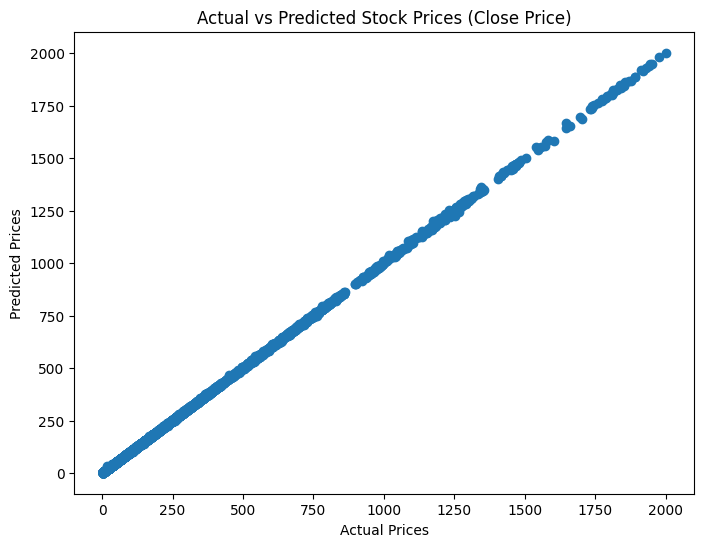

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Stock Prices (Close Price)")
plt.show()

#Task 2: Time Series Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
# Load Dataset
df = pd.read_csv("/content/2) Stock Prices Data Set.csv")

print(df.head())

  symbol        date      open      high       low     close    volume
0    AAL  2014-01-02   25.0700   25.8200   25.0600   25.3600   8998943
1   AAPL  2014-01-02   79.3828   79.5756   78.8601   79.0185  58791957
2    AAP  2014-01-02  110.3600  111.8800  109.2900  109.7400    542711
3   ABBV  2014-01-02   52.1200   52.3300   51.5200   51.9800   4569061
4    ABC  2014-01-02   70.1100   70.2300   69.4800   69.8900   1148391


In [ ]:
# Convert Date Column and Set Date as Index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [ ]:
# Select Closing Price
stock = df['close']

### Original Time Series Plot

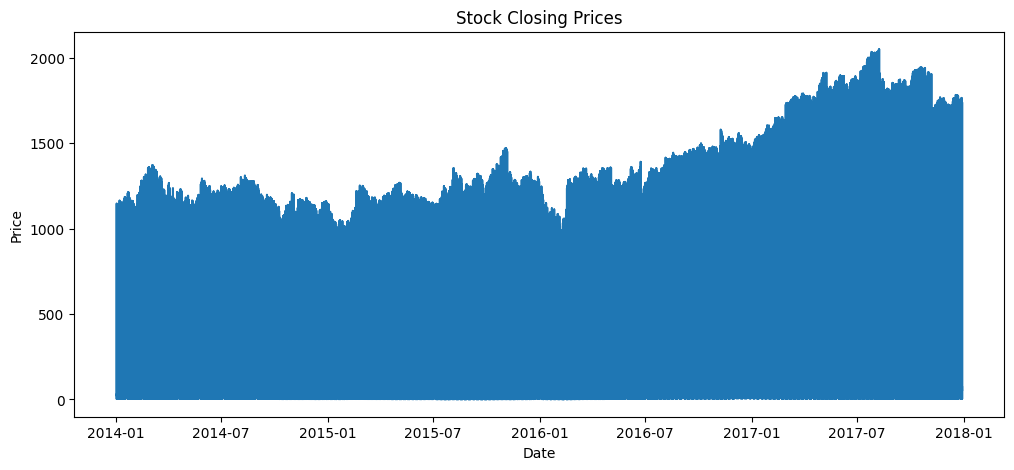

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(stock)
plt.title("Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

### Time Series Decomposition

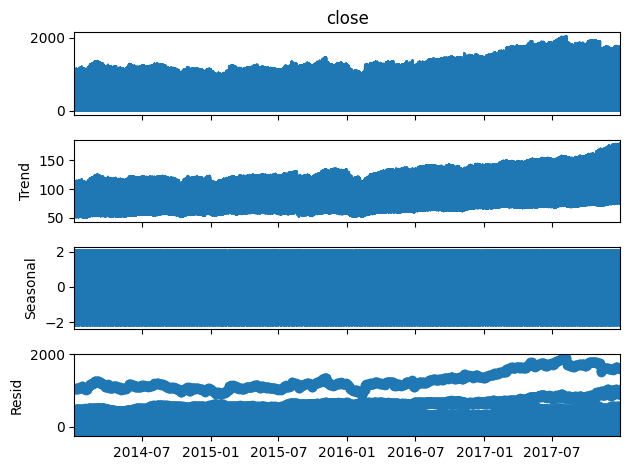

In [ ]:
decomposition = seasonal_decompose(
    stock,
    model='additive',
    period=30
)

decomposition.plot()
plt.show()

### Moving Average Smoothing

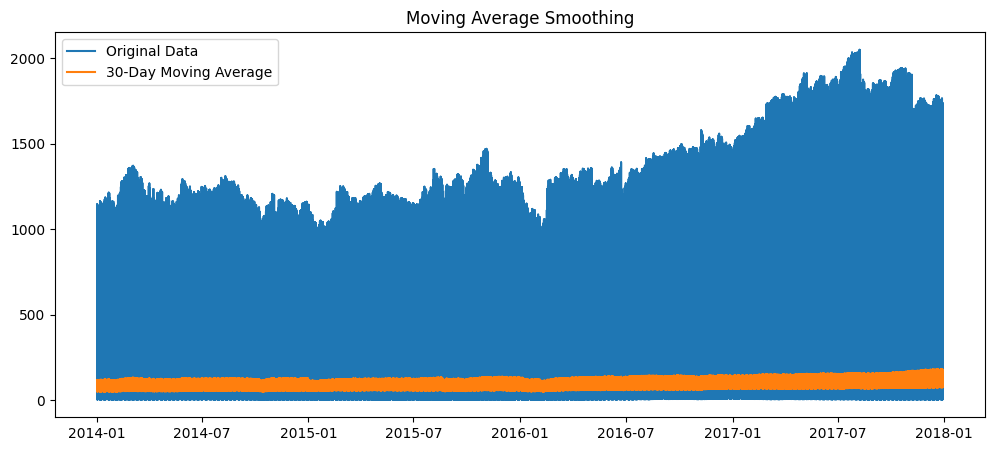

In [ ]:
moving_avg = stock.rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(stock, label='Original Data')
plt.plot(moving_avg, label='30-Day Moving Average')
plt.title("Moving Average Smoothing")
plt.legend()
plt.show()

#Task 3: K-Means Clustering

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load Dataset
df = pd.read_csv("/content/4) house Prediction Data Set.csv", sep=r'\s+', header=None)

In [ ]:
num_cols = df.shape[1]
column_names = [f'feature_{i}' for i in range(num_cols - 1)] + ['price']
df.columns = column_names

data = df.select_dtypes(include=['int64','float64'])

In [ ]:
# Standardization
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

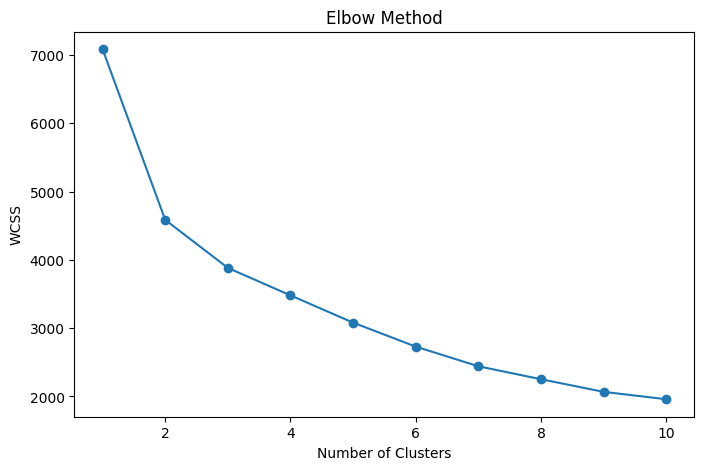

In [ ]:
# Elbow Method

wcss = []

for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
# K-Means Clustering

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

data['Cluster'] = clusters

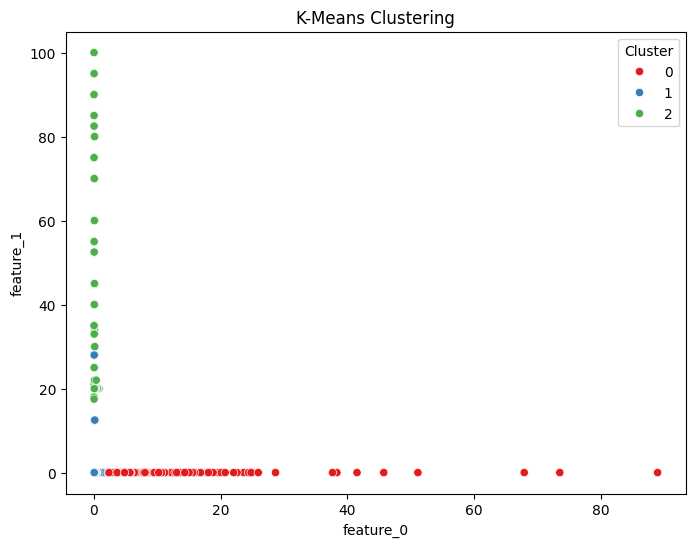

In [ ]:
# Cluster Visualization

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data.iloc[:,0],
    y=data.iloc[:,1],
    hue=data['Cluster'],
    palette='Set1'
)

plt.title("K-Means Clustering")
plt.xlabel(data.columns[0])
plt.ylabel(data.columns[1])

plt.show()

In [ ]:
print("\nCluster Counts:")
print(data['Cluster'].value_counts())


Cluster Counts:
Cluster
1    209
0    156
2    141
Name: count, dtype: int64
